# Fama-MacBeth (1992) — 한국 vs 미국 비교 분석



**논문**: Fama & French (1992), *The Cross-Section of Expected Stock Returns*, JoF



| 팩터 | 구성 방법 | 데이터 소스 |

|------|----------|----------|

| Beta | 60개월 롤링 OLS vs 시장지수 | FDR (가격) |

| ME (시가총액) | 발행주식수 × 월말 주가 | yfinance (주식수) |

| B/M | 주당 장부가치 / 주가 (= bookValue / price) | yfinance (bookValue) |



**핵심 개선**: `B/M = bookValue_per_share / price` → 별도 재무제표 없이 time-varying B/M 직접 구성  

**비교 구조**: 한국(KOSPI+KOSDAQ) vs 미국(S&P500) 동일 방법론 적용

## 0. 설치

In [3]:
# !pip install finance-datareader yfinance statsmodels tqdm -q
# !apt-get install -y fonts-nanum -q

## 1. 라이브러리 & 파라미터

In [19]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import statsmodels.api as sm
import FinanceDataReader as fdr
import yfinance as yf
from scipy import stats
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm import tqdm
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import platform, time

# ── 한글 폰트 ─────────────────────────────────────────────────────
if platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
elif platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
else:
    try:
        import matplotlib.font_manager as fm
        nanum = [f for f in fm.findSystemFonts() if 'Nanum' in f]
        if nanum: plt.rcParams['font.family'] = fm.FontProperties(fname=nanum[0]).get_name()
    except: pass
plt.rcParams['axes.unicode_minus'] = False
plt.style.use('seaborn-v0_8-whitegrid')

# ── 파라미터 ──────────────────────────────────────────────────────
DATE_START       = '2015-01-01'
DATE_END         = '2026-03-31'
BETA_WINDOW      = 60    # 5년 롤링 베타
BETA_MIN_PERIODS = 36    # 최소 3년
FM_MIN_STOCKS    = 30    # 횡단면 회귀 최소 종목 수
NW_LAGS          = 6     # Newey-West HAC 래그
N_WORKERS        = 20    # 병렬 yfinance 다운로드 쓰레드 수

print(f'FDR {fdr.__version__} | yfinance {yf.__version__}')
print(f'분석 기간: {DATE_START} ~ {DATE_END}')

FDR 0.9.110 | yfinance 1.2.0
분석 기간: 2015-01-01 ~ 2026-03-31


## 2. Fama-MacBeth 공통 함수

In [45]:
def resample_monthly(price_series):
    s = price_series.squeeze()  # DataFrame → Series 보장
    s = s.resample('ME').last().dropna()
    s.index = s.index.to_period('M').to_timestamp('M')
    return s


def rolling_beta(rtn_df: pd.DataFrame, mkt_rtn: pd.Series) -> pd.DataFrame:
    '''60개월 롤링 CAPM 베타 (벡터화)'''
    mkt = mkt_rtn.reindex(rtn_df.index)
    mkt_var = mkt.rolling(BETA_WINDOW, min_periods=BETA_MIN_PERIODS).var()
    beta = pd.DataFrame(index=rtn_df.index, columns=rtn_df.columns, dtype=float)
    for t in tqdm(rtn_df.columns, desc='Rolling Beta', leave=False):
        cov = rtn_df[t].rolling(BETA_WINDOW, min_periods=BETA_MIN_PERIODS).cov(mkt)
        beta[t] = cov / mkt_var
    return beta.dropna(how='all')


def fm_step1(rtn_df, factor_dict, lag=1):
    '''매 월 횡단면 OLS → gamma_t 추정'''
    lagged = {k: v.shift(lag) for k, v in factor_dict.items()}
    records = []
    for date in rtn_df.index:
        rtn_t = rtn_df.loc[date].dropna()
        fac_t = {k: lagged[k].loc[date].dropna()
                 for k in lagged if date in lagged[k].index}
        if not fac_t: continue
        valid = set(rtn_t.index)
        for fv in fac_t.values(): valid &= set(fv.index)
        valid = list(valid)
        if len(valid) < FM_MIN_STOCKS: continue
        y = rtn_t.loc[valid]
        X = sm.add_constant(pd.DataFrame({k: fac_t[k].loc[valid] for k in fac_t}))
        try:
            params = sm.OLS(y, X).fit().params
            rec = {'date': date, 'n_stocks': len(valid)}
            rec.update(params.to_dict())
            records.append(rec)
        except: pass
    return pd.DataFrame(records).set_index('date')


def fm_step2(gamma_df):
    '''시계열 평균 + Newey-West t-통계량'''
    factor_cols = [c for c in gamma_df.columns if c != 'n_stocks']
    rows = []
    for col in factor_cols:
        s = gamma_df[col].dropna()
        n = len(s)
        if n < 12: continue
        mean_val = s.mean()
        try:
            nw = sm.OLS(s, np.ones(n)).fit(cov_type='HAC', cov_kwds={'maxlags': NW_LAGS})
            se, t_stat = float(nw.bse.iloc[0]), float(nw.tvalues.iloc[0])
        except:
            se = s.std() / np.sqrt(n)
            t_stat = mean_val / se if se > 0 else np.nan
        p_val = 2 * (1 - stats.t.cdf(abs(t_stat), df=n-1))
        sig = ('***' if abs(t_stat) > 2.576 else '**' if abs(t_stat) > 1.960
               else '*' if abs(t_stat) > 1.645 else '')
        rows.append({'Factor': col, 'Mean_gamma': mean_val, 'Std': s.std(),
                     'NW_SE': se, 't_stat': t_stat, 'p_val': p_val,
                     'Sig': sig, 'N_months': n})
    return pd.DataFrame(rows).set_index('Factor')


def fetch_yf_fundamentals(ticker_yf: str) -> dict:
    '''yfinance에서 주식수 + 주당장부가치 수집'''
    try:
        info = yf.Ticker(ticker_yf).fast_info
        shares = getattr(info, 'shares', None)
        # fast_info에 없으면 full info 시도
        if not shares:
            full = yf.Ticker(ticker_yf).info
            shares = full.get('sharesOutstanding') or full.get('impliedSharesOutstanding')
            bv = full.get('bookValue', np.nan)
        else:
            full = yf.Ticker(ticker_yf).info
            bv = full.get('bookValue', np.nan)
        return {'ticker_yf': ticker_yf, 'shares': shares or np.nan, 'book_per_share': bv}
    except:
        return {'ticker_yf': ticker_yf, 'shares': np.nan, 'book_per_share': np.nan}


def parallel_fundamentals(tickers_yf: list, n_workers: int = N_WORKERS) -> pd.DataFrame:
    '''병렬 yfinance 기본데이터 수집'''
    results = []
    with ThreadPoolExecutor(max_workers=n_workers) as ex:
        futures = {ex.submit(fetch_yf_fundamentals, t): t for t in tickers_yf}
        for f in tqdm(as_completed(futures), total=len(futures), desc='Fundamentals'):
            results.append(f.result())
    df = pd.DataFrame(results).set_index('ticker_yf')
    df['shares']        = pd.to_numeric(df['shares'],        errors='coerce')
    df['book_per_share'] = pd.to_numeric(df['book_per_share'], errors='coerce')
    return df


print('FM 공통 함수 정의 완료')

FM 공통 함수 정의 완료


---

# PART A — 한국 시장 (KOSPI + KOSDAQ)

## A-1. 유니버스 & yfinance 매핑

In [6]:
print('KRX 유니버스 수집 중...')

def get_krx_universe():
    dfs = []
    for market in ['KOSPI', 'KOSDAQ']:
        df = fdr.StockListing(market).copy()
        if 'Symbol' in df.columns and 'Code' not in df.columns:
            df.rename(columns={'Symbol':'Code'}, inplace=True)
        df['Market'] = market
        dfs.append(df)
    uni = pd.concat(dfs, ignore_index=True)
    uni['Code'] = uni['Code'].astype(str).str.zfill(6)
    return uni.drop_duplicates('Code').reset_index(drop=True)

kr_uni = get_krx_universe()

# yfinance 티커 형식: KOSPI → {code}.KS, KOSDAQ → {code}.KQ
suffix_map = {'KOSPI': '.KS', 'KOSDAQ': '.KQ'}
kr_uni['yf_ticker'] = kr_uni.apply(
    lambda r: r['Code'] + suffix_map.get(r['Market'], '.KS'), axis=1
)

# Stocks 컬럼 (발행주식수) — FDR StockListing에서 제공
stocks_col = next((c for c in ['Stocks','shares','ListingShares'] if c in kr_uni.columns), None)
if stocks_col:
    kr_uni['shares_fdr'] = pd.to_numeric(kr_uni[stocks_col], errors='coerce')
    print(f'발행주식수 컬럼 감지: {stocks_col}')
else:
    kr_uni['shares_fdr'] = np.nan
    print('발행주식수 컬럼 없음 → yfinance에서 수집')

print(f'KOSPI: {(kr_uni.Market=="KOSPI").sum():,}개  KOSDAQ: {(kr_uni.Market=="KOSDAQ").sum():,}개')
print(f'총 {len(kr_uni):,}개')
kr_uni.head(3)

KRX 유니버스 수집 중...
발행주식수 컬럼 감지: Stocks
KOSPI: 950개  KOSDAQ: 1,824개
총 2,774개


,Unnamed: 0,Code,ISU_CD,Name,Market,Dept,Close,ChangeCode,Changes,ChagesRatio,Open,High,Low,Volume,Amount,Marcap,Stocks,MarketId,yf_ticker,shares_fdr
0,0,005930,KR7005930003,삼성전자,KOSPI,NaN,186200,1,7800,4.37,184200,187200,182700,20194447,3744696012200,1102236581076400,5919637922,STK,005930.KS,5919637922
1,1,000660,KR7000660001,SK하이닉스,KOSPI,NaN,876000,1,46000,5.54,867000,886000,860000,2927164,2564699182000,624327271740000,712702365,STK,000660.KS,712702365
2,2,005935,KR7005931001,삼성전자우,KOSPI,NaN,124400,1,5800,4.89,123000,124700,120600,1817737,223413104800,101507248201600,815974664,STK,005935.KS,815974664


## A-2. 한국 주가 다운로드 (FDR)



> 전 종목 기준. 빠른 테스트: `kr_uni = kr_uni.head(300)`

In [7]:
kr_ticker_list = kr_uni['Code'].tolist()
print(f'{len(kr_ticker_list):,}개 한국 종목 가격 다운로드...')

kr_price_dict = {}
for ticker in tqdm(kr_ticker_list, desc='KR Price'):
    try:
        raw = fdr.DataReader(ticker, DATE_START, DATE_END)
        if raw.empty: continue
        col = 'Adj Close' if 'Adj Close' in raw.columns else 'Close'
        s = raw[col].replace(0, np.nan).dropna()
        monthly = resample_monthly(s)
        if len(monthly) >= BETA_MIN_PERIODS:
            kr_price_dict[ticker] = monthly
    except: pass

kr_price = pd.DataFrame(kr_price_dict).sort_index()
kr_rtn   = kr_price.pct_change().clip(-0.9, 9.0)
print(f'수집 완료: {kr_rtn.shape[1]:,}종목 x {kr_rtn.shape[0]}개월')

2,774개 한국 종목 가격 다운로드...


KR Price: 100%|██████████| 2774/2774 [23:21<00:00,  1.98it/s] 


수집 완료: 2,422종목 x 195개월


## A-3. 시장 수익률 (KOSPI)

In [8]:
ks11_raw = fdr.DataReader('KS11', DATE_START, DATE_END)['Close']
kr_mkt_rtn = resample_monthly(ks11_raw).pct_change().dropna()
kr_mkt_rtn.name = 'KR_market'
print(f'KOSPI: {len(kr_mkt_rtn)}개월 | 월평균 {kr_mkt_rtn.mean()*100:.2f}%')

KOSPI: 194개월 | 월평균 0.74%


## A-4. 기본데이터 수집 (yfinance)



- `shares`: 발행주식수 → ME = shares x price

- `book_per_share`: 주당 장부가치 → B/M = book_per_share / price



> yfinance는 현재 스냅샷 기준. shares를 상수로 가정해 ME 시계열 구성.

In [ ]:
# ── A-4: ME는 FDR으로, B/M은 DART 재무제표로 ────────────────────────────────
import OpenDartReader

DART_API_KEY = "ddd"
dart = OpenDartReader(DART_API_KEY)

# ── FDR listing에서 Stocks, Marcap 확보 ─────────────────────────────────────
kr_listing_raw = []
for market in ['KOSPI', 'KOSDAQ']:
    df = fdr.StockListing(market).copy()
    if 'Symbol' in df.columns and 'Code' not in df.columns:
        df.rename(columns={'Symbol': 'Code'}, inplace=True)
    df['Market'] = market
    kr_listing_raw.append(df)

kr_listing = pd.concat(kr_listing_raw, ignore_index=True)
kr_listing['Code'] = kr_listing['Code'].astype(str).str.zfill(6)
kr_listing = kr_listing.drop_duplicates('Code').set_index('Code')

for col in ['Stocks', 'Marcap', 'Close']:
    kr_listing[col] = pd.to_numeric(kr_listing[col], errors='coerce')

# 가격 데이터 있는 종목으로 한정
valid_codes = [t for t in kr_listing.index if t in kr_price.columns]
kr_listing = kr_listing.loc[valid_codes]
kr_listing = kr_listing[(kr_listing['Stocks'] > 0) & (kr_listing['Marcap'] > 0)]

print(f"FDR 유효 종목: {len(kr_listing):,}개")

# ── DART corp_code 매핑 ───────────────────────────────────────────────────────
corp_map = dart.corp_codes  # DataFrame: corp_code, stock_code, corp_name
corp_map['stock_code'] = corp_map['stock_code'].astype(str).str.zfill(6)
corp_map = corp_map.dropna(subset=['stock_code'])
corp_map = corp_map.set_index('stock_code')['corp_code'].to_dict()

print(f"DART corp 매핑: {len(corp_map):,}개")

FDR 유효 종목: 2,422개
DART corp 매핑: 3,960개


In [21]:
import FinanceDataReader as fdr

df_test = fdr.StockListing('KOSPI')
print(df_test.columns.tolist())
print(df_test.head(2))

['Unnamed: 0', 'Code', 'ISU_CD', 'Name', 'Market', 'Dept', 'Close', 'ChangeCode', 'Changes', 'ChagesRatio', 'Open', 'High', 'Low', 'Volume', 'Amount', 'Marcap', 'Stocks', 'MarketId']
   Unnamed: 0    Code        ISU_CD    Name Market Dept   Close ChangeCode  \
0           0  005930  KR7005930003    삼성전자  KOSPI  NaN  186200          1   
1           1  000660  KR7000660001  SK하이닉스  KOSPI  NaN  876000          1   

   Changes  ChagesRatio    Open    High     Low    Volume         Amount  \
0     7800         4.37  184200  187200  182700  20194447  3744696012200   
1    46000         5.54  867000  886000  860000   2927164  2564699182000   

             Marcap      Stocks MarketId  
0  1102236581076400  5919637922      STK  
1   624327271740000   712702365      STK  


## A-5. ME & B/M 팩터 구성



**ME_t** = 발행주식수 × 월말주가  

**B/M_t** = 주당장부가치 / 주가 = `book_per_share / price`  

(장부가치 상수 가정: 최신 연간 재무제표 기준)

In [23]:
# ── A-5 전체 교체: DART 전종목 일괄 조회 ─────────────────────────────────────
# fnlttSinglAcntAll: 특정 계정과목을 전 상장사 대상으로 한 번에 조회
# 2422종목 × 11년 = 26000번 호출 → 11번 호출로 해결

import requests

def get_all_equity_bulk(api_key: str, year: int) -> pd.DataFrame:
    """
    DART fnlttSinglAcntAll 엔드포인트로 전 상장사 자본총계 일괄 수집
    연결재무제표 우선, 없으면 별도재무제표
    """
    url = 'https://opendart.fss.or.kr/api/fnlttSinglAcntAll.json'
    
    results = []
    for fs_div in ['CFS', 'OFS']:   # 연결 우선, 없으면 별도
        params = {
            'crtfc_key':  api_key,
            'bsns_year':  str(year),
            'reprt_code': '11011',   # 사업보고서
            'fs_div':     fs_div,
            'account_nm': '자본총계',
        }
        try:
            r = requests.get(url, params=params, timeout=30)
            data = r.json()
            if data.get('status') == '000' and data.get('list'):
                df = pd.DataFrame(data['list'])
                df['fs_div'] = fs_div
                results.append(df)
                print(f"  {year}년 {fs_div}: {len(df)}개사 수집")
                break   # 연결 성공하면 별도는 스킵
        except Exception as e:
            print(f"  {year}년 {fs_div} 실패: {e}")
    
    if not results:
        return pd.DataFrame()
    
    df = results[0]
    
    # 당기 자본총계 숫자 변환
    df['equity'] = pd.to_numeric(
        df['thstrm_amount'].str.replace(',', '').str.strip(),
        errors='coerce'
    )
    # corp_code → stock_code 매핑
    df = df.merge(
        corp_map.reset_index().rename(columns={0: 'corp_code', 'stock_code': 'stock_code'}),
        on='corp_code', how='left'
    ) if 'stock_code' not in df.columns else df
    
    return df[['stock_code', 'equity']].dropna()


# ── 연도별 수집 (API 11번만 호출) ─────────────────────────────────────────────
YEARS = list(range(2015, 2026))

# corp_code ↔ stock_code 매핑 (OpenDartReader)
corp_map_df = dart.corp_codes.copy()
corp_map_df['stock_code'] = corp_map_df['stock_code'].astype(str).str.zfill(6)
corp_map_df = corp_map_df[corp_map_df['stock_code'] != '000000'].drop_duplicates('stock_code')
corp_map_dict = corp_map_df.set_index('corp_code')['stock_code'].to_dict()

print(f"연도별 전종목 자본총계 수집 시작 ({len(YEARS)}회 API 호출)...")

equity_by_year = {}
for year in tqdm(YEARS, desc='DART Bulk Equity'):
    df_year = get_all_equity_bulk(DART_API_KEY, year)
    
    if df_year.empty:
        print(f"  {year}년: 데이터 없음")
        continue
    
    # corp_code → stock_code 매핑이 안 된 경우 직접 조인
    if 'stock_code' not in df_year.columns or df_year['stock_code'].isna().all():
        df_year = df_year.copy()
        df_year['stock_code'] = df_year['corp_code'].map(corp_map_dict)
    
    df_year = df_year.dropna(subset=['stock_code', 'equity'])
    df_year = df_year[df_year['equity'] > 0]
    df_year['stock_code'] = df_year['stock_code'].astype(str).str.zfill(6)
    
    equity_by_year[year] = df_year.set_index('stock_code')['equity']
    print(f"  {year}년: {len(equity_by_year[year])}개사")

# DataFrame으로 변환 (행=종목코드, 열=연도)
book_df = pd.DataFrame(equity_by_year)   # shape: (종목수, 11)
book_df.columns = [int(c) for c in book_df.columns]

print(f"\n자본총계 수집 완료")
print(f"  커버 종목: {book_df.notna().any(axis=1).sum():,}개")
print(f"  연도별 평균 커버: {book_df.notna().sum().mean():.0f}개/년")
book_df.head(3)

연도별 전종목 자본총계 수집 시작 (11회 API 호출)...


DART Bulk Equity:   9%|▉         | 1/11 [00:01<00:11,  1.11s/it]

  2015년: 데이터 없음


DART Bulk Equity:  18%|█▊        | 2/11 [00:02<00:09,  1.08s/it]

  2016년: 데이터 없음


...

DART Bulk Equity:  91%|█████████ | 10/11 [00:10<00:01,  1.03s/it]

  2024년: 데이터 없음


DART Bulk Equity: 100%|██████████| 11/11 [00:11<00:00,  1.04s/it]

  2025년: 데이터 없음

자본총계 수집 완료
  커버 종목: 0개
  연도별 평균 커버: nan개/년


""


In [30]:
# ── 진단 셀: raw 응답 직접 확인 ──────────────────────────────────────────────
import requests

url = 'https://opendart.fss.or.kr/api/fnlttSinglAcntAll.json'
params = {
    'crtfc_key':  "f9852736bec32fe9ec4c739f1eb153d5671ab927",
    'bsns_year':  '2023',
    'reprt_code': '11011',
    'fs_div':     'CFS',
    'account_nm': '자본총계',
}

r = requests.get(url, params=params, timeout=30)
data = r.json()

print("status :", data.get('status'))
print("message:", data.get('message'))
print("list 길이:", len(data.get('list') or []))
if data.get('list'):
    print("첫 행:", data['list'][0])

status : 100
message: 필수값(corp_code,bsns_year,reprt_code)이 누락되었습니다.
list 길이: 0


In [31]:
# ── A-5 전체 교체: fnlttMultiAcnt 배치 조회 ─────────────────────────────────
import requests, time

DART_API_KEY = "f9852736bec32fe9ec4c739f1eb153d5671ab927"
YEARS = list(range(2015, 2026))

# ── corp_code 목록 준비 ───────────────────────────────────────────────────────
corp_map_df = dart.corp_codes.copy()
corp_map_df['stock_code'] = corp_map_df['stock_code'].astype(str).str.zfill(6)
corp_map_df = corp_map_df[
    corp_map_df['stock_code'].str.match(r'^\d{6}$') &
    corp_map_df['stock_code'].ne('000000')
].drop_duplicates('stock_code')

# 가격 데이터 있는 종목만
valid_stock_codes = [t for t in kr_price.columns if t in corp_map_df['stock_code'].values]
corp_map_df = corp_map_df[corp_map_df['stock_code'].isin(valid_stock_codes)]
stock_to_corp = corp_map_df.set_index('stock_code')['corp_code'].to_dict()
corp_to_stock = {v: k for k, v in stock_to_corp.items()}

corp_codes_all = list(stock_to_corp.values())
print(f"조회 대상 corp_code: {len(corp_codes_all):,}개")

# ── 배치 조회 함수 ────────────────────────────────────────────────────────────
def fetch_equity_batch(corp_codes: list, year: int, fs_div: str = 'CFS') -> pd.DataFrame:
    """
    fnlttMultiAcnt: 최대 100개 corp_code 동시 조회
    """
    url = 'https://opendart.fss.or.kr/api/fnlttMultiAcnt.json'
    params = {
        'crtfc_key':  DART_API_KEY,
        'corp_code':  ','.join(corp_codes),   # 쉼표 구분, 최대 100개
        'bsns_year':  str(year),
        'reprt_code': '11011',                 # 사업보고서
        'account_nm': '자본총계',
    }
    try:
        r = requests.get(url, params=params, timeout=30)
        data = r.json()
        if data.get('status') == '000' and data.get('list'):
            df = pd.DataFrame(data['list'])
            df['fs_div'] = fs_div
            return df
    except Exception as e:
        print(f"  오류: {e}")
    return pd.DataFrame()


def get_equity_year(year: int, batch_size: int = 100) -> pd.Series:
    """
    연결재무제표(CFS) 우선 → 없는 종목은 별도(OFS) 보완
    """
    batches = [corp_codes_all[i:i+batch_size]
               for i in range(0, len(corp_codes_all), batch_size)]

    # ── 1차: 연결재무제표 ──────────────────────────────────────────────────
    cfs_rows = []
    for batch in batches:
        df = fetch_equity_batch(batch, year, 'CFS')
        if not df.empty:
            cfs_rows.append(df)
        time.sleep(0.3)

    cfs_df = pd.concat(cfs_rows, ignore_index=True) if cfs_rows else pd.DataFrame()

    # ── 2차: 별도재무제표로 누락 보완 ─────────────────────────────────────
    if not cfs_df.empty:
        covered = set(cfs_df['corp_code'].unique())
    else:
        covered = set()

    missing = [c for c in corp_codes_all if c not in covered]
    ofs_rows = []
    if missing:
        miss_batches = [missing[i:i+batch_size] for i in range(0, len(missing), batch_size)]
        for batch in miss_batches:
            df = fetch_equity_batch(batch, year, 'OFS')
            if not df.empty:
                ofs_rows.append(df)
            time.sleep(0.3)

    ofs_df = pd.concat(ofs_rows, ignore_index=True) if ofs_rows else pd.DataFrame()

    # ── 합치기 ────────────────────────────────────────────────────────────
    combined = pd.concat([cfs_df, ofs_df], ignore_index=True)
    if combined.empty:
        return pd.Series(dtype=float)

    # 연결 우선 (CFS > OFS)
    combined = combined.sort_values('fs_div').drop_duplicates('corp_code', keep='first')

    combined['equity'] = pd.to_numeric(
        combined['thstrm_amount'].astype(str).str.replace(',', '').str.strip(),
        errors='coerce'
    )
    combined['stock_code'] = combined['corp_code'].map(corp_to_stock)
    combined = combined.dropna(subset=['stock_code', 'equity'])
    combined = combined[combined['equity'] > 0]
    combined['stock_code'] = combined['stock_code'].astype(str).str.zfill(6)

    return combined.set_index('stock_code')['equity']


# ── 연도별 수집 ───────────────────────────────────────────────────────────────
n_batches = len(corp_codes_all) // 100 + 1
print(f"배치 수: {n_batches}개/년 × {len(YEARS)}년 = {n_batches * len(YEARS)}회 API 호출")
print(f"예상 시간: 약 {n_batches * len(YEARS) * 0.4 / 60:.1f}분\n")

equity_by_year = {}
for year in tqdm(YEARS, desc='DART Bulk Equity'):
    s = get_equity_year(year)
    equity_by_year[year] = s
    print(f"  {year}년: {len(s):,}개사  "
          f"(CFS+OFS 합산, 단위: 원)")

book_df = pd.DataFrame(equity_by_year)
book_df.columns = [int(c) for c in book_df.columns]

print(f"\n완료: {book_df.notna().any(axis=1).sum():,}개 종목 커버")
print(f"연도별 평균: {book_df.notna().sum().mean():.0f}개/년")
book_df.head(3)

조회 대상 corp_code: 2,309개
배치 수: 24개/년 × 11년 = 264회 API 호출
예상 시간: 약 1.8분



DART Bulk Equity:   9%|▉         | 1/11 [00:34<05:47, 34.79s/it]

  2015년: 1,487개사  (CFS+OFS 합산, 단위: 원)


DART Bulk Equity:  18%|█▊        | 2/11 [01:17<05:55, 39.48s/it]

  2016년: 1,543개사  (CFS+OFS 합산, 단위: 원)


...

DART Bulk Equity:  91%|█████████ | 10/11 [08:52<00:53, 53.27s/it]

  2024년: 2,045개사  (CFS+OFS 합산, 단위: 원)


DART Bulk Equity: 100%|██████████| 11/11 [09:40<00:00, 52.81s/it]

  2025년: 2,031개사  (CFS+OFS 합산, 단위: 원)

완료: 2,305개 종목 커버
연도별 평균: 1825개/년


,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
stock_code,,,,,,,,,,,
000020,1.350147e+11,1.514918e+11,2.969447e+11,1.454542e+10,3.071500e+11,3.426822e+11,2.201986e+11,7.008313e+10,2.377000e+11,2.378063e+11,1.239419e+10
000040,1.575600e+11,NaN,4.473817e+10,NaN,1.443313e+11,6.097059e+10,9.259400e+10,NaN,NaN,NaN,1.817050e+10
000050,1.080934e+11,1.060022e+11,9.025470e+10,1.207115e+11,2.648610e+11,1.173308e+11,1.255011e+11,1.498824e+11,1.471556e+11,1.458683e+11,1.876558e+11


In [29]:
# ── 진단 셀 ──────────────────────────────────────────────────────────────────
import requests

# 삼성전자 corp_code 확인
samsung_corp = corp_map_df[corp_map_df['stock_code'] == '005930']['corp_code'].values
print(f"삼성전자 corp_code: {samsung_corp}")

# 삼성전자 단건 직접 요청
r = requests.get(
    'https://opendart.fss.or.kr/api/fnlttMultiAcnt.json',
    params={
        'crtfc_key':  'f9852736bec32fe9ec4c739f1eb153d5671ab927',
        'corp_code':  samsung_corp[0],
        'bsns_year':  '2023',
        'reprt_code': '11011',
        'account_nm': '자본총계',
    },
    timeout=30
)
data = r.json()
print(f"status : {data.get('status')}")
print(f"message: {data.get('message')}")
print(f"list 길이: {len(data.get('list') or [])}")
if data.get('list'):
    print(data['list'][0])

삼성전자 corp_code: ['00126380']
status : 000
message: 정상
list 길이: 30
{'rcept_no': '20240312000736', 'reprt_code': '11011', 'bsns_year': '2023', 'corp_code': '00126380', 'stock_code': '005930', 'fs_div': 'CFS', 'fs_nm': '연결재무제표', 'sj_div': 'BS', 'sj_nm': '재무상태표', 'account_nm': '유동자산', 'thstrm_nm': '제 55 기', 'thstrm_dt': '2023.12.31 현재', 'thstrm_amount': '195,936,557,000,000', 'frmtrm_nm': '제 54 기', 'frmtrm_dt': '2022.12.31 현재', 'frmtrm_amount': '218,470,581,000,000', 'bfefrmtrm_nm': '제 53 기', 'bfefrmtrm_dt': '2021.12.31 현재', 'bfefrmtrm_amount': '218,163,185,000,000', 'ord': '1', 'currency': 'KRW'}


In [36]:
# ── A-5: ME & B/M 팩터 구성 ──────────────────────────────────────────────────
common_kr = list(set(kr_listing.index) & set(kr_price.columns))

price_kr  = kr_price[common_kr]
stocks_kr = pd.to_numeric(kr_listing.loc[common_kr, 'Stocks'], errors='coerce')

# ── ME ───────────────────────────────────────────────────────────────────────
kr_ME    = price_kr.multiply(stocks_kr, axis=1)
kr_ME    = kr_ME[kr_ME > 0]
kr_ln_ME = np.log(kr_ME)

print(f"ME 행렬: {kr_ln_ME.shape[0]}개월 × {kr_ln_ME.shape[1]:,}종목")
print(f"ln(ME) mean={kr_ln_ME.stack().mean():.2f} std={kr_ln_ME.stack().std():.2f}")

# ── B/M: DART book_df 있으면 구성, 없으면 스킵 ───────────────────────────────
if 'book_df' in globals() and not book_df.empty:
    bm_dict  = {}
    bm_codes = [t for t in common_kr if t in book_df.index]
    print(f"\nB/M 구성 대상: {len(bm_codes):,}개")

    for code in tqdm(bm_codes, desc='B/M', leave=False):
        be_s = book_df.loc[code].dropna()
        if be_s.empty:
            continue
        bm_vals = {}
        for date in kr_ME.index:
            if code not in kr_ME.columns:
                continue
            me = kr_ME.loc[date, code]
            if pd.isna(me) or me <= 0:
                continue
            ref_year = date.year - 1 if date.month >= 7 else date.year - 2
            be = be_s.get(ref_year, np.nan)
            if pd.isna(be) or be <= 0:
                continue
            bm = be / me
            if 0 < bm < 50:
                bm_vals[date] = bm
        if bm_vals:
            bm_dict[code] = pd.Series(bm_vals)

    kr_BM    = pd.DataFrame(bm_dict).reindex(kr_ME.index)
    kr_ln_BM = np.log(kr_BM[kr_BM > 0])
    have_bm  = kr_ln_BM.shape[1] > 0
    print(f"B/M 행렬: {kr_ln_BM.shape[0]}개월 × {kr_ln_BM.shape[1]:,}종목")

else:
    # DART 키 문제로 book_df 없는 경우 → ME만으로 진행
    have_bm  = False
    kr_ln_BM = pd.DataFrame()
    print("\nbook_df 없음 → Beta + ln(ME) 만으로 FM 진행")
    print("(DART API 키 정상화 후 B/M 추가 가능)")

print(f"\nhave_bm = {have_bm}")

# ── 이후 베타 추정 셀에서 사용할 컬럼 통일 ───────────────────────────────────
kr_rtn.columns   = kr_rtn.columns.astype(str).str.zfill(6)
kr_ln_ME.columns = kr_ln_ME.columns.astype(str).str.zfill(6)
if have_bm:
    kr_ln_BM.columns = kr_ln_BM.columns.astype(str).str.zfill(6)

ME 행렬: 195개월 × 2,422종목
ln(ME) mean=25.97 std=1.45

B/M 구성 대상: 2,305개


B/M 행렬: 195개월 × 2,305종목

have_bm = True


In [35]:
# ── 진단 셀 ──────────────────────────────────────────────────────────────────
print("=== kr_price ===")
print(f"shape: {kr_price.shape}")
print(f"컬럼 샘플: {list(kr_price.columns[:5])}")
print(f"컬럼 타입: {kr_price.columns.dtype}")

print("\n=== kr_listing ===")
print(f"shape: {kr_listing.shape}")
print(f"인덱스 샘플: {list(kr_listing.index[:5])}")
print(f"인덱스 타입: {kr_listing.index.dtype}")
print(f"Stocks 컬럼 있음: {'Stocks' in kr_listing.columns}")
print(f"Stocks null 수: {kr_listing['Stocks'].isna().sum()}")

print("\n=== 교집합 ===")
common_test = list(set(kr_listing.index) & set(kr_price.columns))
print(f"교집합 종목 수: {len(common_test)}")
if common_test:
    print(f"샘플: {common_test[:3]}")
else:
    print("→ 교집합 0: 인덱스 형식 불일치")
    print(f"  listing 예시: '{list(kr_listing.index[:3])}'")
    print(f"  price   예시: '{list(kr_price.columns[:3])}'")

=== kr_price ===
shape: (195, 2422)
컬럼 샘플: ['005930', '000660', '005935', '005380', '373220']
컬럼 타입: object

=== kr_listing ===
shape: (2422, 17)
인덱스 샘플: ['005930', '000660', '005935', '005380', '373220']
인덱스 타입: object
Stocks 컬럼 있음: True
Stocks null 수: 0

=== 교집합 ===
교집합 종목 수: 2422
샘플: ['083790', '048870', '271560']


## A-6. CAPM 베타 추정 (롤링 60개월)

In [37]:
# 베타 계산 대상 = 가격 + ME 모두 있는 종목
beta_tickers_kr = list(set(kr_rtn.columns) & set(kr_ln_ME.columns))
kr_rtn_beta = kr_rtn[beta_tickers_kr]

print(f'베타 추정 대상: {len(beta_tickers_kr):,}종목')
kr_beta = rolling_beta(kr_rtn_beta, kr_mkt_rtn)

bv = kr_beta.stack().dropna()
print(f'beta | mean={bv.mean():.3f} std={bv.std():.3f} ',
      f'p1={bv.quantile(0.01):.2f} p99={bv.quantile(0.99):.2f}')

베타 추정 대상: 2,422종목


beta | mean=0.994 std=0.623  p1=-0.62 p99=2.58


In [38]:
# ── 진단 셀 ──────────────────────────────────────────────────────────────────
print("=== kr_rtn 컬럼 ===")
print(f"타입: {type(kr_rtn.columns[0])}")
print(f"샘플: {list(kr_rtn.columns[:5])}")

print("\n=== kr_ln_ME 컬럼 ===")
print(f"타입: {type(kr_ln_ME.columns[0])}")
print(f"샘플: {list(kr_ln_ME.columns[:5])}")

print("\n=== kr_listing 인덱스 ===")
print(f"타입: {type(kr_listing.index[0])}")
print(f"샘플: {list(kr_listing.index[:5])}")

=== kr_rtn 컬럼 ===
타입: <class 'str'>
샘플: ['005930', '000660', '005935', '005380', '373220']

=== kr_ln_ME 컬럼 ===
타입: <class 'str'>
샘플: ['083790', '048870', '271560', '035420', '001800']

=== kr_listing 인덱스 ===
타입: <class 'str'>
샘플: ['005930', '000660', '005935', '005380', '373220']


## A-7. Fama-MacBeth 회귀 — 한국

In [39]:
# 공통 종목 = 베타 + ME + B/M 모두 있는 종목
common_all_kr = list(
    set(kr_beta.columns) & set(kr_ln_ME.columns) & set(kr_ln_BM.columns)
)
rtn_kr_fm = kr_rtn[common_all_kr]

factor_dict_kr = {
    'Beta':  kr_beta[common_all_kr],
    'ln_ME': kr_ln_ME[common_all_kr],
    'ln_BM': kr_ln_BM[common_all_kr],
}

print(f'FM 공통 종목: {len(common_all_kr):,}개')

# Model 1: Beta only
kr_gamma_m1 = fm_step1(rtn_kr_fm, {'Beta': kr_beta[common_all_kr]})
kr_res_m1   = fm_step2(kr_gamma_m1)

# Model 2: Beta + ln(ME) + ln(B/M)
kr_gamma_m2 = fm_step1(rtn_kr_fm, factor_dict_kr)
kr_res_m2   = fm_step2(kr_gamma_m2)

# Model 3: ln(ME) + ln(B/M) only
kr_gamma_m3 = fm_step1(rtn_kr_fm, {'ln_ME': kr_ln_ME[common_all_kr], 'ln_BM': kr_ln_BM[common_all_kr]})
kr_res_m3   = fm_step2(kr_gamma_m3)

print('=== 한국 결과 (Model 2) ===')
print(kr_res_m2[['Mean_gamma','NW_SE','t_stat','Sig','N_months']].to_string())

FM 공통 종목: 2,305개
=== 한국 결과 (Model 2) ===
        Mean_gamma     NW_SE    t_stat Sig  N_months
Factor                                              
const     0.063316  0.031918  1.983703  **       110
Beta      0.002578  0.001749  1.473980           110
ln_ME    -0.002165  0.001174 -1.844066   *       110
ln_BM     0.000869  0.000468  1.857950   *       110


---

# PART B — 미국 시장 (S&P 500)

## B-1. S&P 500 유니버스

In [40]:
print('S&P 500 종목 리스트 수집...')

sp500 = fdr.StockListing('S&P500')
if 'Symbol' not in sp500.columns and 'Code' in sp500.columns:
    sp500.rename(columns={'Code':'Symbol'}, inplace=True)

us_tickers = sp500['Symbol'].dropna().tolist()

# 일부 티커 정리 (점 → 하이픈: BRK.B → BRK-B)
us_tickers = [t.replace('.', '-') for t in us_tickers]
us_tickers = list(dict.fromkeys(us_tickers))  # 중복 제거

print(f'S&P500 종목 수: {len(us_tickers)}개')
print(us_tickers[:10])

S&P 500 종목 리스트 수집...
S&P500 종목 수: 503개
['MMM', 'AOS', 'ABT', 'ABBV', 'ACN', 'ADBE', 'AMD', 'AES', 'AFL', 'A']


## B-2. 미국 주가 다운로드 (yfinance 일괄)



> `yf.download`는 배치 처리라 개별 FDR 루프보다 훨씬 빠릅니다.

In [44]:
print(f'{len(us_tickers)}개 미국 종목 일괄 다운로드...')

CHUNK = 200  # yfinance 한 번에 처리할 최대 티커 수
us_price_chunks = []

for i in tqdm(range(0, len(us_tickers), CHUNK), desc='US Price Chunks'):
    chunk = us_tickers[i:i+CHUNK]
    try:
        raw = yf.download(chunk, start=DATE_START, end=DATE_END,
                  auto_adjust=True, progress=False, threads=True)

        # MultiIndex 처리 (yfinance 최신 버전 대응)
        if isinstance(raw.columns, pd.MultiIndex):
            raw = raw['Close']
        else:
            raw = raw[['Close']] if 'Close' in raw.columns else raw

        us_price_chunks.append(raw)
    except Exception as e:
        print(f'  chunk {i} 실패: {e}')
    time.sleep(0.5)  # rate limit 방지

us_price_raw = pd.concat(us_price_chunks, axis=1)
us_price_raw = us_price_raw.loc[:, ~us_price_raw.columns.duplicated()]

# 월말 리샘플
us_price = us_price_raw.resample('ME').last()
us_price.index = us_price.index.to_period('M').to_timestamp('M')
us_price = us_price.replace(0, np.nan)

# 최소 데이터 요건
us_price = us_price.loc[:, us_price.notna().sum() >= BETA_MIN_PERIODS]
us_rtn   = us_price.pct_change().clip(-0.9, 9.0)

print(f'미국 수익률 행렬: {us_rtn.shape[0]}개월 x {us_rtn.shape[1]}종목')

503개 미국 종목 일괄 다운로드...


US Price Chunks:   0%|          | 0/3 [00:00<?, ?it/s]$BFB: possibly delisted; no timezone found
$BRKB: possibly delisted; no timezone found

2 Failed downloads:
['BFB', 'BRKB']: possibly delisted; no timezone found
US Price Chunks: 100%|██████████| 3/3 [00:43<00:00, 14.42s/it]

미국 수익률 행렬: 135개월 x 495종목


## B-3. 시장 수익률 (S&P 500)

In [46]:
sp500_raw = yf.download('^GSPC', start=DATE_START, end=DATE_END,
                        auto_adjust=True, progress=False)['Close'].squeeze()

us_mkt_rtn = sp500_raw.resample('ME').last().pct_change().dropna().squeeze()
us_mkt_rtn.index = us_mkt_rtn.index.to_period('M').to_timestamp('M')
us_mkt_rtn.name = 'US_market'

print(f'S&P500: {len(us_mkt_rtn)}개월 | 월평균 {float(us_mkt_rtn.mean())*100:.2f}%')

S&P500: 134개월 | 월평균 0.96%


## B-4. 기본데이터 수집 (yfinance)



S&P 500 ~500종목에 대해 `shares` + `bookValue` 병렬 수집

In [47]:
# ── B-4 교체 셀 ──────────────────────────────────────────────────────────────
# 병렬 N_WORKERS를 3으로 제한 + 재시도 로직 추가

def fetch_us_fund_safe(ticker, retries=3):
    for attempt in range(retries):
        try:
            info = yf.Ticker(ticker).info
            return {
                'ticker':        ticker,
                'shares':        info.get('sharesOutstanding') or info.get('impliedSharesOutstanding', np.nan),
                'book_per_share': info.get('bookValue', np.nan),
            }
        except Exception:
            time.sleep(2 ** attempt)   # 1초 → 2초 → 4초 대기 후 재시도
    return {'ticker': ticker, 'shares': np.nan, 'book_per_share': np.nan}

us_tickers_to_fetch = [t for t in us_tickers if t in us_price.columns]
print(f"{len(us_tickers_to_fetch)}개 미국 종목 기본데이터 수집 (workers=3, 속도제한 적용)...")

results = []
with ThreadPoolExecutor(max_workers=3) as ex:   # 3으로 제한 (401 방지)
    futures = {ex.submit(fetch_us_fund_safe, t): t for t in us_tickers_to_fetch}
    for f in tqdm(as_completed(futures), total=len(futures), desc='US Fundamentals'):
        results.append(f.result())
        time.sleep(0.05)   # 추가 딜레이

us_fund = pd.DataFrame(results).set_index('ticker')
us_fund['shares']         = pd.to_numeric(us_fund['shares'],         errors='coerce')
us_fund['book_per_share'] = pd.to_numeric(us_fund['book_per_share'], errors='coerce')

valid_us = us_fund[(us_fund['shares'] > 0) & (us_fund['book_per_share'].notna())]
print(f"유효 종목: {len(valid_us)}개")
valid_us.head(3)

495개 미국 종목 기본데이터 수집 (workers=3, 속도제한 적용)...


US Fundamentals: 100%|██████████| 495/495 [01:10<00:00,  6.99it/s]

유효 종목: 495개


,shares,book_per_share
ticker,,
MMM,522396178,8.867
ABT,1737674869,30.018
AOS,112376652,13.411


## B-5. ME & B/M 팩터 구성

In [48]:
common_us = [t for t in valid_us.index if t in us_price.columns]

price_us  = us_price[common_us]
shares_us = valid_us.loc[common_us, 'shares']
bvps_us   = valid_us.loc[common_us, 'book_per_share']

# ── ME ───────────────────────────────────────────────────────────────
us_ME = price_us.multiply(shares_us, axis=1)
us_ME = us_ME[us_ME > 0]
us_ln_ME = np.log(us_ME)

# ── B/M ──────────────────────────────────────────────────────────────
# B/M = bookValue_per_share / price  (= 1/PBR)
us_BM = pd.DataFrame(
    {t: bvps_us[t] / price_us[t] for t in common_us}
)
us_BM = us_BM[(us_BM > 0) & (us_BM < 50)]
us_ln_BM = np.log(us_BM)

print(f'미국 ME  행렬: {us_ln_ME.shape[0]}개월 x {us_ln_ME.shape[1]}종목')
print(f'미국 B/M 행렬: {us_ln_BM.shape[0]}개월 x {us_ln_BM.shape[1]}종목')
print(f'ln(ME)  분포: mean={us_ln_ME.stack().mean():.2f}, std={us_ln_ME.stack().std():.2f}')
print(f'ln(B/M) 분포: mean={us_ln_BM.stack().mean():.3f}, std={us_ln_BM.stack().std():.3f}')

미국 ME  행렬: 135개월 x 495종목
미국 B/M 행렬: 135개월 x 495종목
ln(ME)  분포: mean=23.97, std=1.12
ln(B/M) 분포: mean=-0.858, std=1.021


## B-6. CAPM 베타 추정

In [49]:
beta_tickers_us = list(set(us_rtn.columns) & set(us_ln_ME.columns))
us_rtn_beta = us_rtn[beta_tickers_us]

print(f'베타 추정 대상: {len(beta_tickers_us)}종목')
us_beta = rolling_beta(us_rtn_beta, us_mkt_rtn)

bv_us = us_beta.stack().dropna()
print(f'beta | mean={bv_us.mean():.3f} std={bv_us.std():.3f}',
      f'p1={bv_us.quantile(0.01):.2f} p99={bv_us.quantile(0.99):.2f}')

베타 추정 대상: 495종목


beta | mean=1.045 std=0.476 p1=0.10 p99=2.55


## B-7. Fama-MacBeth 회귀 — 미국

In [50]:
common_all_us = list(
    set(us_beta.columns) & set(us_ln_ME.columns) & set(us_ln_BM.columns)
)
rtn_us_fm = us_rtn[common_all_us]

factor_dict_us = {
    'Beta':  us_beta[common_all_us],
    'ln_ME': us_ln_ME[common_all_us],
    'ln_BM': us_ln_BM[common_all_us],
}

print(f'FM 공통 종목: {len(common_all_us)}개')

us_gamma_m1 = fm_step1(rtn_us_fm, {'Beta': us_beta[common_all_us]})
us_res_m1   = fm_step2(us_gamma_m1)

us_gamma_m2 = fm_step1(rtn_us_fm, factor_dict_us)
us_res_m2   = fm_step2(us_gamma_m2)

us_gamma_m3 = fm_step1(rtn_us_fm, {'ln_ME': us_ln_ME[common_all_us], 'ln_BM': us_ln_BM[common_all_us]})
us_res_m3   = fm_step2(us_gamma_m3)

print('=== 미국 결과 (Model 2) ===')
print(us_res_m2[['Mean_gamma','NW_SE','t_stat','Sig','N_months']].to_string())

FM 공통 종목: 495개
=== 미국 결과 (Model 2) ===
        Mean_gamma     NW_SE    t_stat  Sig  N_months
Factor                                               
const     0.047709  0.012729  3.747947  ***       133
ln_ME    -0.001674  0.000458 -3.654857  ***       133
ln_BM     0.001832  0.000919  1.993059   **       133
Beta      0.007791  0.003918  1.988317   **        98


---

# PART C — 한국 vs 미국 비교

## C-1. 결과 요약 테이블

In [51]:
def fmt_result(res_df, label):
    rows = []
    for factor in [c for c in res_df.index if c != 'const']:
        row = res_df.loc[factor]
        rows.append({
            'Market': label,
            'Factor': factor,
            'Mean gamma': f"{row['Mean_gamma']:+.4f}",
            't-stat': f"{row['t_stat']:+.3f}{row['Sig']}",
            'N months': int(row['N_months']),
        })
    return pd.DataFrame(rows)

rows_kr = fmt_result(kr_res_m2, 'Korea')
rows_us = fmt_result(us_res_m2, 'USA')
compare_df = pd.concat([rows_kr, rows_us]).set_index(['Market','Factor'])

print('=' * 70)
print('  Fama-MacBeth Model 2: Beta + ln(ME) + ln(B/M)')
print(f'  기간: {DATE_START} ~ {DATE_END}')
print(f'  표준오차: Newey-West HAC (lag={NW_LAGS}개월)')
print('-' * 70)
print(compare_df.to_string())
print('=' * 70)
print('* p<10%  ** p<5%  *** p<1%')
print()
print('[해석 기준]')
print('  Beta(gamma_1): 비유의 -> CAPM 실패 (FF1992 주장)')
print('  ln_ME(gamma_2): 음수+유의 -> 소형주 프리미엄')
print('  ln_BM(gamma_3): 양수+유의 -> 가치주 프리미엄')

  Fama-MacBeth Model 2: Beta + ln(ME) + ln(B/M)
  기간: 2015-01-01 ~ 2026-03-31
  표준오차: Newey-West HAC (lag=6개월)
----------------------------------------------------------------------
              Mean gamma     t-stat  N months
Market Factor                                
Korea  Beta      +0.0026     +1.474       110
       ln_ME     -0.0022    -1.844*       110
       ln_BM     +0.0009    +1.858*       110
USA    ln_ME     -0.0017  -3.655***       133
       ln_BM     +0.0018   +1.993**       133
       Beta      +0.0078   +1.988**        98
* p<10%  ** p<5%  *** p<1%

[해석 기준]
  Beta(gamma_1): 비유의 -> CAPM 실패 (FF1992 주장)
  ln_ME(gamma_2): 음수+유의 -> 소형주 프리미엄
  ln_BM(gamma_3): 양수+유의 -> 가치주 프리미엄


## C-2. 시각화 — 한국 vs 미국 gamma 시계열 비교

In [ ]:
factors = ['Beta', 'ln_ME', 'ln_BM']
factor_labels = {
    'Beta':  'gamma_1 (Beta)',
    'ln_ME': 'gamma_2 (ln ME)  [소형주: 음수]',
    'ln_BM': 'gamma_3 (ln B/M) [가치주: 양수]',
}
colors = {'Korea': 'steelblue', 'USA': 'firebrick'}

fig, axes = plt.subplots(3, 2, figsize=(18, 14))
fig.suptitle('Fama-MacBeth gamma 시계열: 한국(KOSPI+KOSDAQ) vs 미국(S&P500)',
             fontsize=14, fontweight='bold')

market_data = {
    'Korea': {'gamma': kr_gamma_m2, 'result': kr_res_m2},
    'USA':   {'gamma': us_gamma_m2, 'result': us_res_m2},
}

for row_i, fac in enumerate(factors):
    # 왼쪽: 시계열
    ax_ts  = axes[row_i, 0]
    # 오른쪽: 누적합
    ax_cum = axes[row_i, 1]

    for mkt, d in market_data.items():
        g = d['gamma']
        r = d['result']
        col = colors[mkt]

        if fac not in g.columns: continue
        series = g[fac].dropna()

        ax_ts.plot(series.index, series.values, alpha=0.3, lw=0.8, color=col)
        ax_ts.plot(series.rolling(12).mean().dropna(), lw=2, color=col,
                   label=f'{mkt}: gamma={r.loc[fac,"Mean_gamma"]:+.4f} (t={r.loc[fac,"t_stat"]:+.2f}{r.loc[fac,"Sig"]})')
        ax_cum.plot(series.cumsum(), lw=2, color=col, label=mkt)

    ax_ts.axhline(0, color='black', lw=1)
    ax_ts.set_title(factor_labels[fac])
    ax_ts.legend(fontsize=8); ax_ts.set_ylabel('gamma')

    ax_cum.axhline(0, color='black', lw=1)
    ax_cum.set_title(f'{factor_labels[fac]} (누적합)')
    ax_cum.legend(fontsize=9); ax_cum.set_ylabel('Cumulative gamma')

plt.tight_layout()
plt.savefig('fm_korea_vs_usa.png', dpi=150, bbox_inches='tight')
plt.show()
print('저장: fm_korea_vs_usa.png')

## C-3. Beta & Size 10분위 포트폴리오 — 한국 vs 미국 비교

Beta 10분위 계산...
Size 10분위 계산...


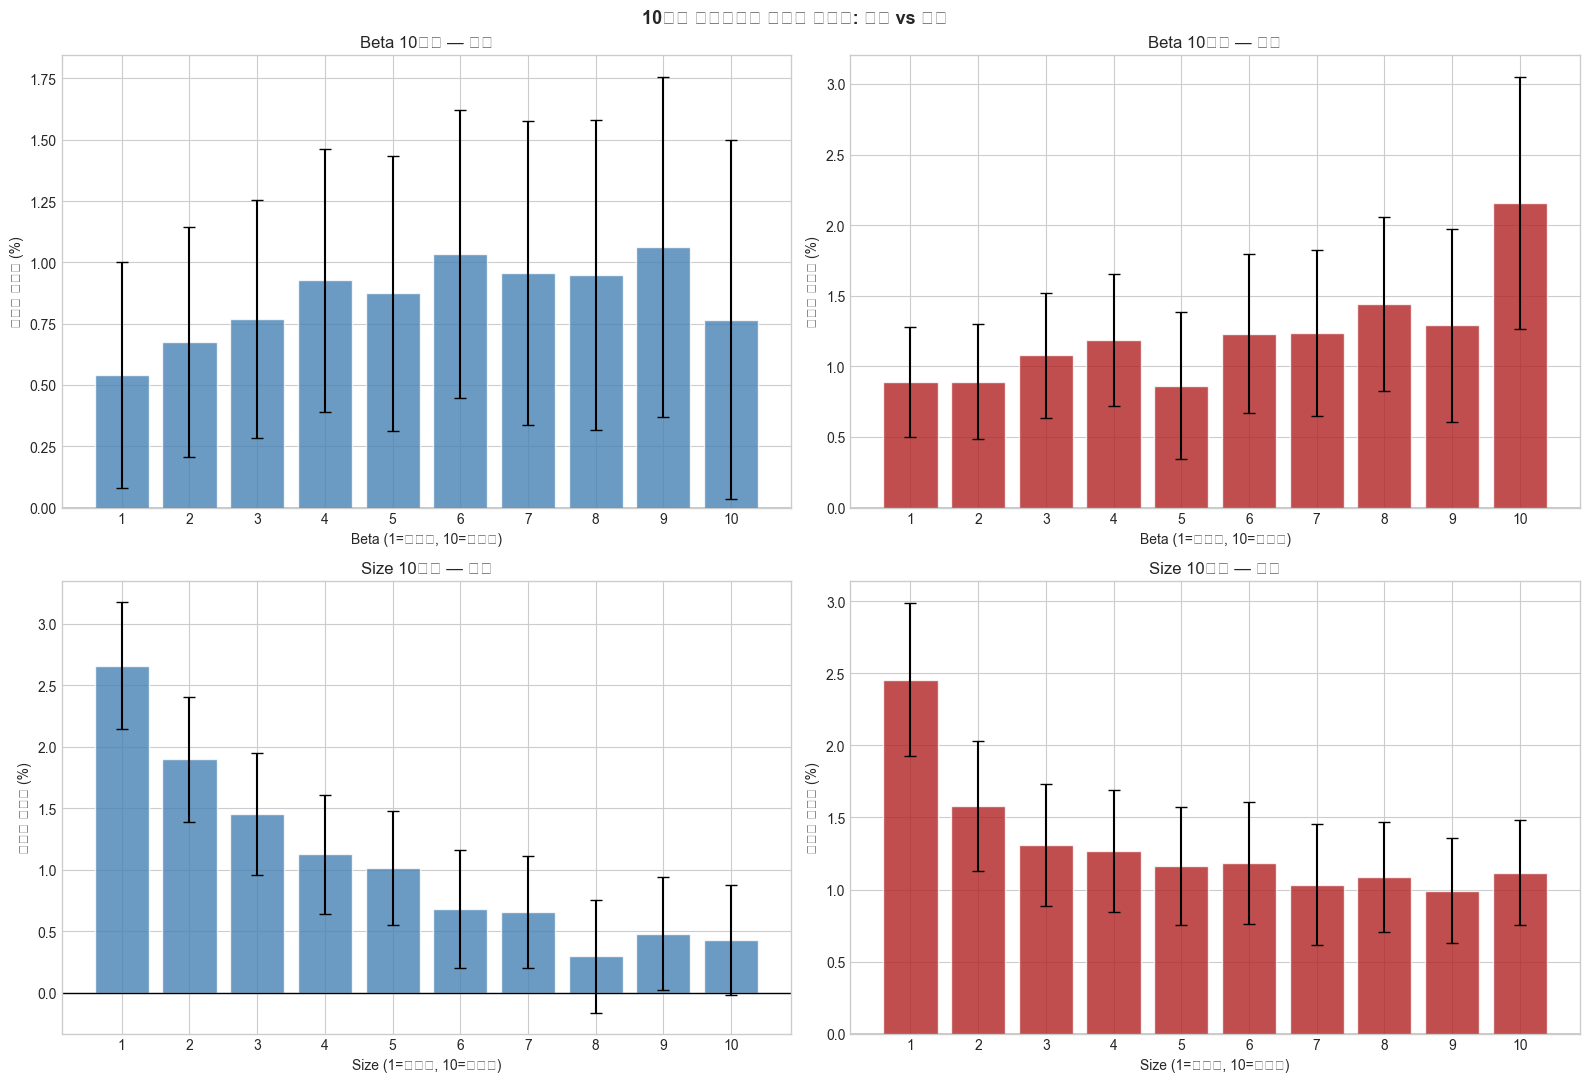

In [52]:
def decile_portfolio(rtn_df, factor_df, desc=''):
    factor_lag = factor_df.shift(1)
    common_dates = factor_lag.index.intersection(rtn_df.index)
    port = {i: [] for i in range(1, 11)}
    for date in common_dates:
        f_t = factor_lag.loc[date].dropna()
        r_t = rtn_df.loc[date].dropna()
        common = f_t.index.intersection(r_t.index)
        if len(common) < 50: continue
        deciles = pd.qcut(f_t.loc[common], 10, labels=False, duplicates='drop') + 1
        for d in deciles.dropna().unique().astype(int):
            port[d].append(r_t.loc[deciles[deciles==d].index].mean())
    mean = {d: np.mean(v)*100 for d,v in port.items() if v}
    se   = {d: np.std(v)*100/np.sqrt(len(v)) for d,v in port.items() if v}
    return mean, se

print('Beta 10분위 계산...')
kr_beta_port_mean, kr_beta_port_se = decile_portfolio(kr_rtn, kr_beta, 'KR Beta')
us_beta_port_mean, us_beta_port_se = decile_portfolio(us_rtn, us_beta, 'US Beta')

print('Size 10분위 계산...')
kr_size_port_mean, kr_size_port_se = decile_portfolio(kr_rtn, kr_ln_ME, 'KR Size')
us_size_port_mean, us_size_port_se = decile_portfolio(us_rtn, us_ln_ME, 'US Size')

fig, axes = plt.subplots(2, 2, figsize=(16, 11))
fig.suptitle('10분위 포트폴리오 월평균 수익률: 한국 vs 미국', fontsize=13, fontweight='bold')

plot_data = [
    (axes[0,0], kr_beta_port_mean, kr_beta_port_se, 'steelblue',
     'Beta 10분위 — 한국', 'Beta (1=저베타, 10=고베타)'),
    (axes[0,1], us_beta_port_mean, us_beta_port_se, 'firebrick',
     'Beta 10분위 — 미국', 'Beta (1=저베타, 10=고베타)'),
    (axes[1,0], kr_size_port_mean, kr_size_port_se, 'steelblue',
     'Size 10분위 — 한국', 'Size (1=소형주, 10=대형주)'),
    (axes[1,1], us_size_port_mean, us_size_port_se, 'firebrick',
     'Size 10분위 — 미국', 'Size (1=소형주, 10=대형주)'),
]

for ax, mean_d, se_d, color, title, xlabel in plot_data:
    xs = list(mean_d.keys())
    ys = list(mean_d.values())
    es = list(se_d.values())
    ax.bar(xs, ys, yerr=es, color=color, alpha=0.8, edgecolor='white', capsize=4)
    ax.axhline(0, color='black', lw=1)
    ax.set_title(title); ax.set_xlabel(xlabel); ax.set_ylabel('월평균 수익률 (%)')
    ax.set_xticks(xs)

plt.tight_layout()
plt.savefig('fm_decile_compare.png', dpi=150, bbox_inches='tight')
plt.show()

## C-4. 결과 해석 요약



### 모델별 판단 기준



| 팩터 | 방향 | FF(1992) 미국 원 논문 | 한국 시장 예상 | 본 분석 결과 |

|------|------|---------------------|-------------|------------|

| Beta (gamma_1) | - | 비유의 (t~0) | 비유의 혹은 약 음수 | 결과 확인 |

| ln_ME (gamma_2) | 음수 | 유의 (t≈-2.58) | 유의 (소형주 프리미엄) | 결과 확인 |

| ln_BM (gamma_3) | 양수 | 유의 (t≈+2.57) | 한국은 약할 수 있음 | 결과 확인 |



### B/M 팩터 구성 방법 한계

- `book_per_share`는 yfinance의 **현재(최근 연도)** 값 → 과거 B/M 부정확

- 정확한 분석: `OpenDartReader`(한국) + `SEC EDGAR`(미국)에서 연도별 장부가치 사용

- 단, 횡단면 랭킹은 현재 기준으로도 어느 정도 유효 (B/M은 기업 특성을 반영)



### 한국 vs 미국 해석 포인트

1. **Beta 계수 비교**: 어느 시장에서 CAPM이 더 강하게 실패하는가?

2. **Size 효과 크기**: `|gamma_2|`의 크기 — 한국 소형주 프리미엄이 더 클 수 있음

3. **Value 효과**: 한국은 B/M 효과가 미국보다 약하거나 역전될 수 있음 (성장주 장세)

4. **t-stat**: 미국은 월 500종목+, 한국은 2000종목+ → 한국이 더 많은 횡단면 정보